# Lab 12 — Critério de Nyquist e Atraso de Transporte

**Módulo 03 · Semana 12 · Laboratório de Controle Automático (Ifes Guarapari)**

Neste laboratório você vai:
1. Traçar o **gráfico de Nyquist** e aplicar o critério $Z = N + P$;
2. Analisar uma planta **instável em malha aberta** (margem **inferior** de ganho);
3. Ver o **atraso de transporte** drenar a margem de fase e desenhar a **espiral** de Nyquist;
4. Simular o atraso via **aproximação de Padé** e medir a degradação no degrau.

Teoria de referência: `teoria_modulo3.md`, seção **§3.3** (figuras `m3_fig15` a `m3_fig23`).

In [1]:
# %% IMPORTS (rode esta célula primeiro)
!pip install --quiet control==0.10.2
import control as ct
import numpy as np
import matplotlib.pyplot as plt
import math
plt.rcParams['figure.figsize'] = (9, 4)
plt.rcParams['axes.grid'] = True

def step(G, t):
    t, y = ct.step_response(G, t)
    return np.asarray(t), np.asarray(y)   # python-control 0.10.2: converte NamedSignal

def medir(T, t=None):
    # Mede Mp (%), tp, tr(0-100%) e ts(5%) da resposta ao degrau de T.
    if t is None: t = np.linspace(0, 50, 20000)
    t, y = step(T, t)
    yss = y[-1]
    Mp = 100*(y.max() - yss)/yss
    tp = t[np.argmax(y)]
    tr = t[np.argmax(y >= yss)]
    fora = np.where(np.abs(y - yss) > 0.05*abs(yss))[0]
    ts = t[fora[-1]] if len(fora) else 0.0
    return dict(Mp=Mp, tp=tp, tr=tr, ts=ts, yss=yss)

def mp(G, w):
    # Módulo (vezes) e fase (graus) de G em w (rad/s).
    mag, ph, _ = ct.frequency_response(G, np.atleast_1d(w))
    return np.asarray(mag).ravel(), np.degrees(np.asarray(ph).ravel())

def mf(G):
    return ct.feedback(G, 1)

print('python-control', ct.__version__)
def nxy(G, w):
    # Gráfico de Nyquist: parte real e imaginária de G(jω).
    m, p = mp(G, w)
    z = m*np.exp(1j*np.radians(p))
    return z.real, z.imag


[notice] A new release of pip is available: 25.0.1 -> 26.2
[notice] To update, run: pip install --upgrade pip


python-control 0.10.2


## Parte 1 — Nyquist e a faixa de estabilidade em K

Seja $G(s) = \dfrac{K}{s(s+1)(s+2)}$. A planta tem **$P = 0$** polos no SPD (o polo na origem é contornado pela indentação, §3.3.4) → estabilidade exige **$N = 0$**: a curva não pode circular o ponto $-1$.

Analiticamente (confira na mão!): a fase vale $-180°$ em $\omega = \sqrt{2}$ e $|G(j\sqrt{2})| = K/6$ → o cruzamento com o eixo real é em $-K/6$ → estável para $0 < K < 6$.

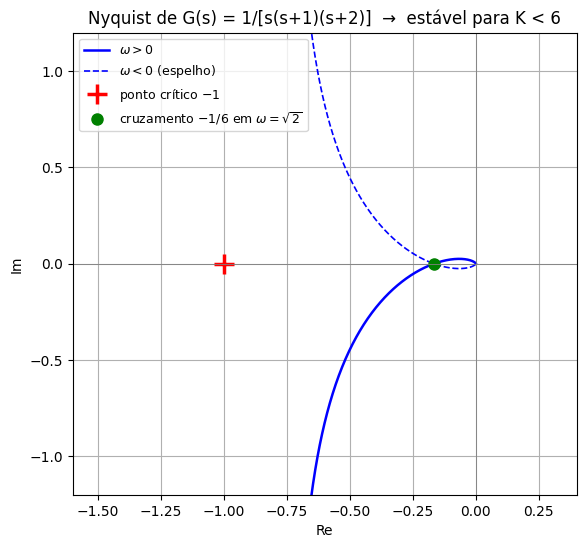

K = 3: polos de MF = [-2.672+0.j    -0.164+1.047j -0.164-1.047j]  →  0 polo(s) no SPD
K = 6: polos de MF = [-3.+0.j     0.+1.414j  0.-1.414j]  →  0 polo(s) no SPD
K = 8: polos de MF = [-3.166+0.j     0.083+1.587j  0.083-1.587j]  →  2 polo(s) no SPD


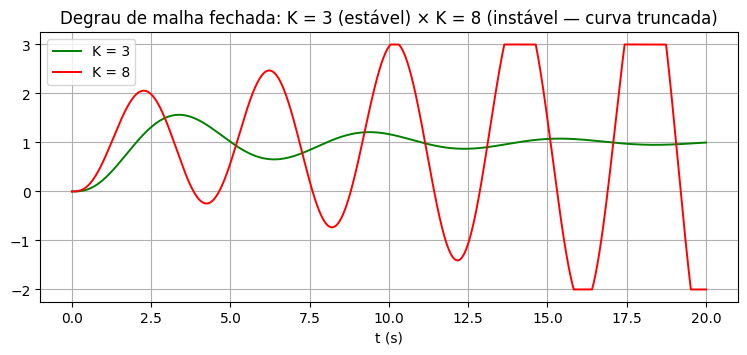

In [2]:
G = ct.tf([1], [1, 3, 2, 0])   # K = 1
w = np.logspace(-1, 1, 800)
X, Y = nxy(G, w)

fig, ax = plt.subplots(figsize=(6.5, 6))
ax.plot(X, Y, 'b', lw=1.8, label='$\\omega > 0$')
ax.plot(X, -Y, 'b--', lw=1.2, label='$\\omega < 0$ (espelho)')
ax.plot(-1, 0, 'r+', ms=14, mew=2.5, label='ponto crítico $-1$')
ax.plot(-1/6, 0, 'go', ms=8, label='cruzamento $-1/6$ em $\\omega=\\sqrt{2}$')
ax.axhline(0, color='gray', lw=0.6); ax.axvline(0, color='gray', lw=0.6)
ax.set_xlim(-1.6, 0.4); ax.set_ylim(-1.2, 1.2)
ax.set_xlabel('Re'); ax.set_ylabel('Im'); ax.legend(fontsize=9)
ax.set_title('Nyquist de G(s) = 1/[s(s+1)(s+2)]  →  estável para K < 6')
plt.show()

for K in [3, 6, 8]:
    polos = ct.poles(mf(K*G))
    inst = np.sum(polos.real > 1e-9)
    print(f'K = {K}: polos de MF = {np.round(polos, 3)}  →  {inst} polo(s) no SPD')

t = np.linspace(0, 20, 20000)
fig, ax = plt.subplots(figsize=(9, 3.5))
for K, cor in [(3, 'g'), (8, 'r')]:
    tt, y = step(K*G/(1+K*G) if False else mf(K*G), t)
    ax.plot(tt, np.clip(y, -2, 3), cor, lw=1.4, label=f'K = {K}')
ax.set_title('Degrau de malha fechada: K = 3 (estável) × K = 8 (instável — curva truncada)')
ax.set_xlabel('t (s)'); ax.legend(); plt.show()

### ✏️ Responda no relatório

**Q1.1** Conte as voltas em torno de $-1$ para $K = 3$ e para $K = 8$ (desenhe a curva de $K=8$ modificando o código). $Z = N + P$ bate com os polos de malha fechada impressos?

**Q1.2** Confira a faixa $0 < K < 6$ por Routh-Hurwitz (característico $s^3 + 3s^2 + 2s + K$). O que o polinômio auxiliar diz sobre a frequência de oscilação no limite?

**Q1.3** Qual a GM para $K = 3$? Marque-a no gráfico de Nyquist (dica: é a distância do cruzamento até $-1$, em dB).

## Parte 2 — Planta instável em malha aberta: a margem INFERIOR de ganho

Seja $G(s) = \dfrac{s+2}{(s+1)(s-5)}$ — agora **$P = 1$** (polo em $+5$). Estabilidade de malha fechada exige $Z = N + 1 = 0$, ou seja, **$N = -1$**: a curva precisa dar **uma volta anti-horária** em $-1$. Isso só acontece para $K$ **grande o suficiente** — existe uma margem **inferior** de ganho.

Analiticamente: a curva cruza o eixo real em $-0{,}25\,K$ quando $\omega = \sqrt{3}$ → precisa $-0{,}25K < -1$ → $K > 4$. Routh confirma: característico $s^2 + (K-4)s + (2K-5)$ → $K > 4$ (e $K > 2{,}5$).

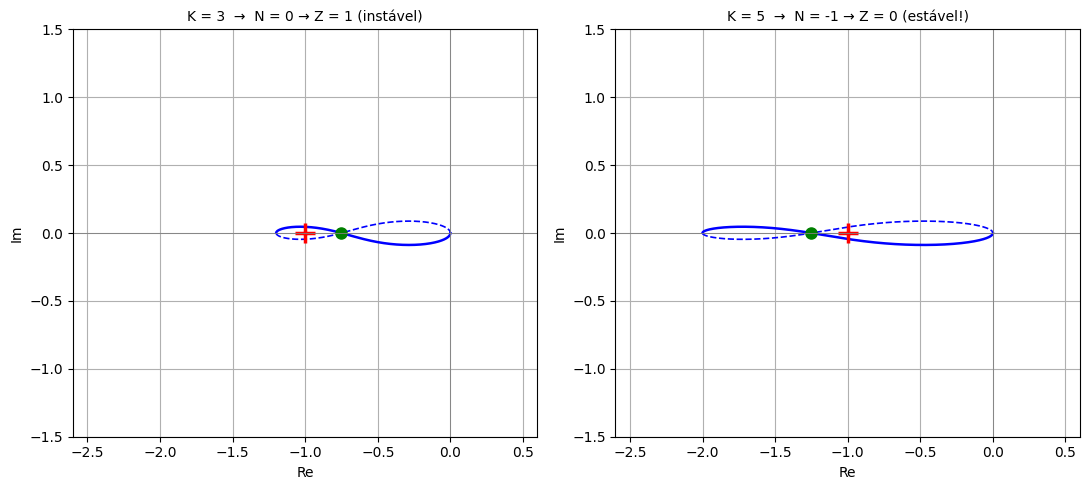

K = 3: polos de MF = [0.5+0.866j 0.5-0.866j]  →  2 polo(s) no SPD
K = 4: polos de MF = [-0.+1.732j  0.-1.732j]  →  0 polo(s) no SPD
K = 5: polos de MF = [-0.5+2.179j -0.5-2.179j]  →  0 polo(s) no SPD

K = 5: y(∞) = 2.001  (T(0) = -2/(1-2) = 2 — confira na mão!)


In [3]:
G = ct.tf([1, 2], [1, -4, -5])   # (s+2)/[(s+1)(s-5)]
w = np.logspace(-2, 3, 4000)
X, Y = nxy(G, w)

fig, axes = plt.subplots(1, 2, figsize=(11, 5))
for ax, K, tit in [(axes[0], 3, 'K = 3  →  N = 0 → Z = 1 (instável)'),
                   (axes[1], 5, 'K = 5  →  N = -1 → Z = 0 (estável!)')]:
    ax.plot(K*X, Y, 'b', lw=1.8)
    ax.plot(K*X, -Y, 'b--', lw=1.2)
    ax.plot(-1, 0, 'r+', ms=14, mew=2.5)
    ax.plot(-0.25*K, 0, 'go', ms=8)
    ax.axhline(0, color='gray', lw=0.6); ax.axvline(0, color='gray', lw=0.6)
    ax.set_xlim(-2.6, 0.6); ax.set_ylim(-1.5, 1.5)
    ax.set_title(tit, fontsize=10); ax.set_xlabel('Re'); ax.set_ylabel('Im')
plt.tight_layout(); plt.show()

for K in [3, 4, 5]:
    polos = ct.poles(mf(K*G))
    inst = np.sum(polos.real > 1e-9)
    print(f'K = {K}: polos de MF = {np.round(polos, 3)}  →  {inst} polo(s) no SPD')
# resposta ao degrau com K = 5: yss = T(0) = KG(0)/(1+KG(0))
r = medir(mf(5*G), np.linspace(0, 12, 20000))
print(f'\nK = 5: y(∞) = {r["yss"]:.3f}  (T(0) = -2/(1-2) = 2 — confira na mão!)')

### ✏️ Responda no relatório

**Q2.1** Explique, com $Z = N + P$, por que $K = 3$ é instável e $K = 5$ é estável — o contrário da intuição do Lab 12 Parte 1!

**Q2.2** O que acontece **exatamente** em $K = 4$? Onde estão os polos de malha fechada?

**Q2.3** Refaça a conta do cruzamento: mostre que $\mathrm{Im}\,G(j\omega) = 0$ em $\omega = \sqrt{3}$ e que $G(j\sqrt{3}) = -0{,}25$. (Compare com a figura `m3_fig20`.)

## Parte 3 — Atraso de transporte: a fase que escorre

Seja $G(s) = \dfrac{4}{(s+0{,}1)(s+1)}\,e^{-0{,}2s}$. O atraso $e^{-\delta s}$ tem **módulo 1** (não toca a curva de ganho!) e fase $-\delta\omega$ — que cresce sem limite com $\omega$.

**Custo na PM (§3.3.7):** $\Delta\mathrm{PM} = -\delta\,\omega_c$ (em radianos).

ωc = 1.88 rad/s (o atraso NÃO muda o módulo)
PM sem atraso = 31.1°   →   perda = δ·ωc = 21.5°   →   PM com atraso = 9.6°


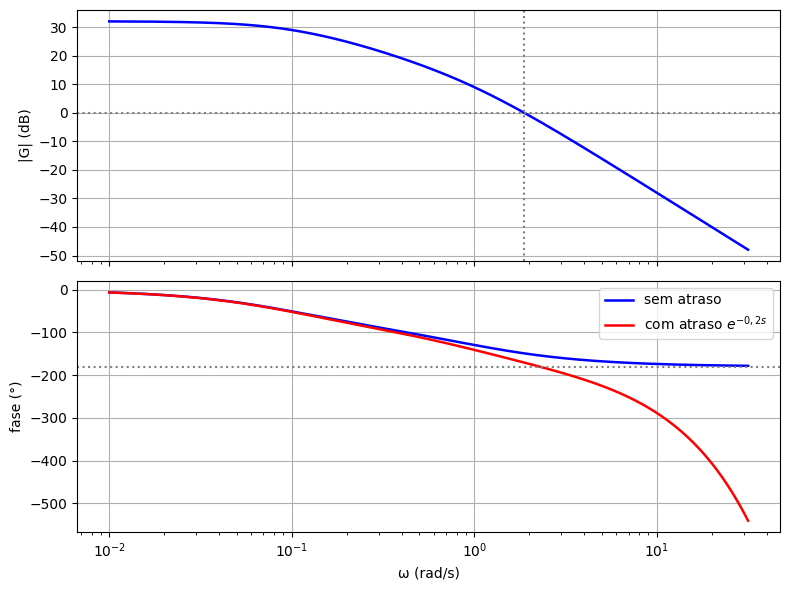

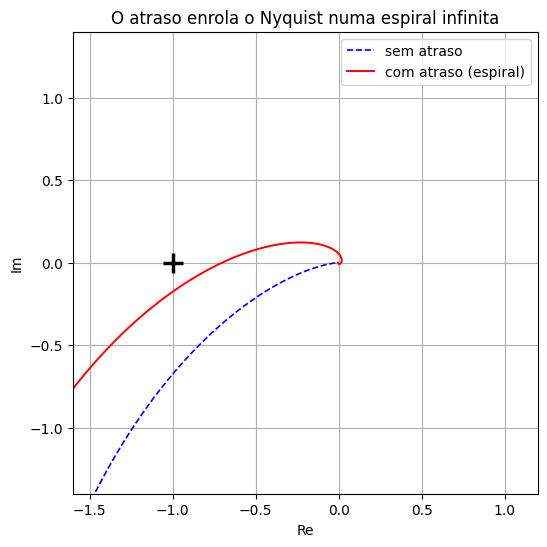

In [4]:
Gn = ct.tf([4], [1, 1.1, 0.1])   # planta sem atraso
delta = 0.2
w = np.logspace(-2, 1.5, 3000)
m, p = mp(Gn, w)
mdb = 20*np.log10(m)
iwc = np.argmin(np.abs(mdb)); wc = w[iwc]
PM_sem = p[iwc] + 180
perda = np.degrees(delta*wc)
PM_com = PM_sem - perda
print(f'ωc = {wc:.2f} rad/s (o atraso NÃO muda o módulo)')
print(f'PM sem atraso = {PM_sem:.1f}°   →   perda = δ·ωc = {perda:.1f}°   →   PM com atraso = {PM_com:.1f}°')

fig, (axm, axf) = plt.subplots(2, 1, figsize=(8, 6), sharex=True)
axm.semilogx(w, mdb, 'b', lw=1.8); axm.axhline(0, color='gray', ls=':')
axm.axvline(wc, color='gray', ls=':'); axm.set_ylabel('|G| (dB)')
axf.semilogx(w, p, 'b', lw=1.8, label='sem atraso')
axf.semilogx(w, p - np.degrees(delta*w), 'r', lw=1.8, label='com atraso $e^{-0,2s}$')
axf.axhline(-180, color='gray', ls=':')
axf.set_ylabel('fase (°)'); axf.set_xlabel('ω (rad/s)'); axf.legend()
plt.tight_layout(); plt.show()

# Nyquist: a espiral do atraso
X, Y = nxy(Gn, w)
pa = np.radians(p - np.degrees(delta*w))
Xa, Ya = m*np.cos(pa), m*np.sin(pa)
fig, ax = plt.subplots(figsize=(6, 6))
ax.plot(X, Y, 'b--', lw=1.2, label='sem atraso')
ax.plot(Xa, Ya, 'r', lw=1.4, label='com atraso (espiral)')
ax.plot(-1, 0, 'k+', ms=14, mew=2.5)
ax.set_xlim(-1.6, 1.2); ax.set_ylim(-1.4, 1.4)
ax.set_xlabel('Re'); ax.set_ylabel('Im'); ax.legend()
ax.set_title('O atraso enrola o Nyquist numa espiral infinita')
plt.show()

### Aproximação de Padé: simulando o atraso no tempo

O Python não simula $e^{-\delta s}$ diretamente — usa-se a **aproximação de Padé de ordem 8** (`ct.pade`), excelente para $\delta\omega$ na faixa da banda de passagem.

sem atraso: Mp = 41.2%,  tr = 0.95 s
com atraso: Mp = 79.4%,  tr = 1.04 s
previsão pela PM: ζ 0.31 → 0.10  (Mp previsto: 36% → 74%)


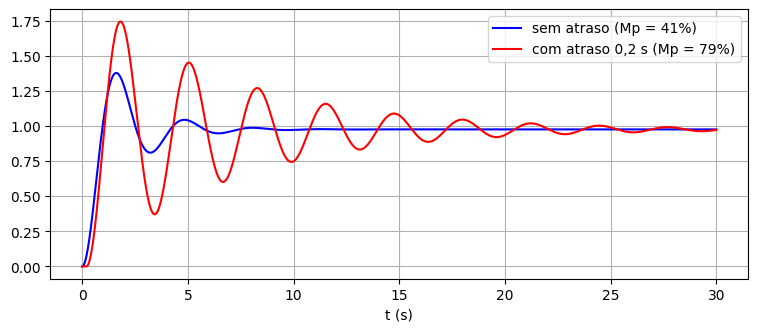

In [5]:
num, den = ct.pade(delta, 8)
Gd = Gn*ct.tf(num, den)

t = np.linspace(0, 30, 60000)  # horizonte longo: a malha com atraso oscila muito (PM = 9,6°)
r0 = medir(mf(Gn), t)
rd = medir(mf(Gd), t)
print(f'sem atraso: Mp = {r0["Mp"]:.1f}%,  tr = {r0["tr"]:.2f} s')
print(f'com atraso: Mp = {rd["Mp"]:.1f}%,  tr = {rd["tr"]:.2f} s')
xi0, xid = PM_sem/100, PM_com/100
print(f'previsão pela PM: ζ {xi0:.2f} → {xid:.2f}  (Mp previsto: '
      f'{100*math.exp(-math.pi*xi0/math.sqrt(1-xi0**2)):.0f}% → '
      f'{100*math.exp(-math.pi*xid/math.sqrt(max(1e-9,1-xid**2))):.0f}%)')

tt, y0 = step(mf(Gn), t); _, yd = step(mf(Gd), t)
fig, ax = plt.subplots(figsize=(9, 3.5))
ax.plot(tt, y0, 'b', lw=1.5, label=f'sem atraso (Mp = {r0["Mp"]:.0f}%)')
ax.plot(tt, yd, 'r', lw=1.5, label=f'com atraso 0,2 s (Mp = {rd["Mp"]:.0f}%)')
ax.set_xlabel('t (s)'); ax.legend(); plt.show()

### ✏️ Responda no relatório

**Q3.1** Por que a curva de **módulo** do Bode não muda com o atraso? Escreva $|e^{-j\delta\omega}|$.

**Q3.2** A perda de PM é $\delta\,\omega_c$. Se dobrássemos a banda ($\omega_c$), qual seria o custo do mesmo atraso de $0{,}2$ s? O que isso implica para o projeto de sistemas rápidos com atraso?

**Q3.3** Compare a degradação prevista (pela PM) com a simulada (Padé). Por que a simulação é um pouco pior que a previsão?

---

## Encerramento

Nyquist responde "estável ou não?" (e "com que margem?") direto da resposta em frequência — inclusive para plantas instáveis em malha aberta e com atraso, casos em que Routh e o LGR ficam desajeitados. O atraso de transporte é o grande vilão: módulo intacto, fase drenando $-\delta\omega$ — no Lab 13 e 14 você verá que **todo compensador precisa deixar PM de sobra** por causa dele.